## CMPE-257, Machine Learning, Summer 2025
## Week 2: Statistical Learning Theory

In this workbook, you will be exporing a simple regression problem:

- approximating an unknown function
- model complexity and learning
- sample complexity and learning
- exploring the effects of noise
- term project team formation

In [1]:
# YOUR NAME: Quoc Dung Lam

In [6]:
# Loading required modules
import random as rd
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import pylab

## PART 1: Approximating an Unknown Function

In [4]:
# The following six functions provide the basis for the exporatory work you will be
# conducting in this coding session, study them and make sure you understand what they do

# GETGXVALS: computes g(x) for a given g() and set of x values
# GETFXVALS: computes f(x) = cos(x) for a given set of x values
# GETNOISE: computes noise (gaussian distribution, zero mean and specified variance)
# GETDATA: uses the three previos functions to compute a dataset and all associated values
# GETMSE: computes the mean square error between two lists of values
# GETOPTGX: finds the best fit (constant, linear, or quadratic) for a given set of points

# GETGXVALS: evaluates a given hypothesis gx over a set of provided data points xvals
# - gx: a list containing the coeficients of the model [a,...] -> a + b x + c x^2 + ...
# - xvals: a list of x values for which g(x) is to be computed
def getgxvals(gx,xvals):
    return [sum([r*x**i for i,r in enumerate(gx)]) for x in xvals]

# GETFXVALS: evaluates the generative funtion f(x)=cos(x) over a set of data points xvals
# - xvals: a list of x values for which f(x) is to be computed
def getfxvals(xvals):
    return [np.cos(x) for x in xvals]

# GETNOISE: produces random samples with gaussian distribution, zero mean and specified variance
# - vr: the desired variance value (float) for the resuting noise sequence
# - nspl: the desired number of random samples (int) in the resuting noise sequence
def getnoise(vr,nspl):
    tmp = [rd.gauss(0.0,vr**0.5) for x in range(nspl)]
    return [x-np.mean(tmp) for x in tmp]

# GETDATA: generates a dataset (dict) for experimental purposes. Input parameters include:
# - xvals: either the number of data points (int) or the specific x values to be used (list)
# - rnd: if TRUE, a random set of points is generated, if FALSE points are uniformly 
#   distributed between xmin and xman (if xvals is a list, rnd is ignored)
# - nvr: the desired variance for the additive noise component n -> y = f(x) + n
# - xmin: minimum value of x to be considered (if x values are generated, i.e. xvals is int)
# - xmax: maximum value of x to be considered (if x values are generated, i.e. xvals is int)
def getdata(xvals,rnd=False,nvr=0.0,xmin=0.0,xmax=4.55):
    if type(xvals) is list:
        ndata = len(xvals)
        xx = xvals
    elif rnd:
        ndata = int(xvals)
        xx = sorted([rd.uniform(xmin,xmax) for x in range(ndata)])
    else:
        ndata = int(xvals)
        xx = [(xmax-xmin)/ndata*t-xmin for t in range(ndata)]
    ff = getfxvals(xx)
    nn = getnoise(nvr,ndata)
    yy = [x+y for x,y in zip(ff,nn)]
    return {'x':xx,'f':ff,'n':nn,'y':yy,'nvar':nvr}

# GETMSE: computes de mean square error (MSE) between two lists of values
# - yvals: the set of values being evaluated
# - yrefs: the set of reference values to conduct the evaluation 
def getmse(yvals,yrefs):
    return sum([(yr-yv)**2 for yr,yv in zip(yrefs,yvals)])/len(yrefs)

# GETOPTGX: computes the optimal model (best fit) for a given set of data points
# - xvals: a list containing the x coordinates of the data points
# - yvals: a lits containing the y coordinates of the data points
# - order: the order of the model to be used (0: constant, 1: linear, 2: quadratic)
# Note 1: this function uses the closed solutions derived in class
# Note 2: models are returned as a list of coefficients, starting with the lowest order one
def getoptgx(xvals,yvals,order):
    ns = len(xvals)
    if order==0:
        k = sum(yvals)/len(yvals)
        gx = [k]
    elif order==1:
        sx = sum(xvals)
        sy = sum(yvals)
        sxy = sum([x*y for x,y in zip(xvals,yvals)])
        sx2 = sum([x**2 for x in xvals])
        m = (ns*sxy-sx*sy)/(ns*sx2-sx**2)
        b = (sy-m*sx)/ns
        gx = [b,m]
    elif order==2:
        sx = sum(xvals)
        sx2 = sum([x**2 for x in xvals])
        sx3 = sum([x**3 for x in xvals])
        sx4 = sum([x**4 for x in xvals])
        sy = sum(yvals)
        syx = sum([y*x for x,y in zip(xvals,yvals)])
        syx2 = sum([y*x**2 for x,y in zip(xvals,yvals)])
        bn = (ns*syx2-sy*sx2)*(ns*sx3-sx*sx2)-(ns*syx-sy*sx)*(ns*sx4-sx2**2)
        bd = (ns*sx3-sx*sx2)**2-(ns*sx2-sx**2)*(ns*sx4-sx2**2)
        b = bn/bd
        a = (ns*syx-sy*sx-b*(ns*sx2-sx**2))/(ns*sx3-sx*sx2)
        c = (sy-a*sx2-b*sx)/ns
        gx = [c,b,a]
    return gx

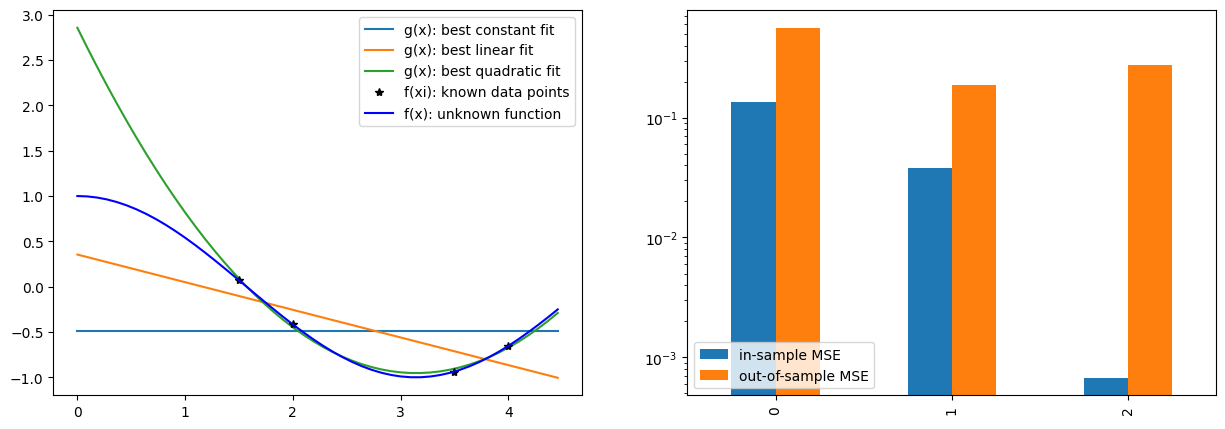

In [5]:
# Exercise #1: reproduce results presented in class for approximating an unknown f(X), 
# use the folowing values of x for the in-sample dataset [1.50,2.00,3.50,4.00], and
# consider three different model types: constant, linear, and quadratic 

fig, ax = plt.subplots(1,2,figsize=(15,5))
tags = ['constant','linear','quadratic']
results = []
models = []

in_sample_data = [1.50,2.00,3.50,4.00]

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):
    
    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))
    
    predictions = getgxvals(model,out_sample['x'])
    outmse = getmse(out_sample['y'],predictions)
    
    results.append({'Model Order':tags[k],'in-sample MSE':inmse,'out-of-sample MSE':outmse})
    models.append(model)

    ax[0].plot(out_sample['x'],predictions,label='g(x): best '+tags[k]+' fit')

ax[0].plot(in_sample['x'],in_sample['y'],'*k',label='f(xi): known data points')
ax[0].plot(out_sample['x'],out_sample['f'],'-b',label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar',logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()

In [6]:
# Exercise 1 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.136458,0.037702,0.000675
out-of-sample MSE,0.562852,0.186096,0.275623


In [7]:
# How results in exercises #1 compare to the example presented in class?
# For both #1 and in-class example, the constant models produce the highest MSE for both in-sample and out-of-sample
# The Linear models come in 2nd for both #1 and in-class example, but the in-sample MSE in class is better than #1 here.
# The Quadratic models produce the best MSE for in-sample, but both have the worse MSE compared to Linear.
# The results in exercises #1 is similar to the result presented in class, with an exception where the in-sample MSE of Linear model of #1 is not as good as in-class example.

In [8]:
def generate_random_model(k_order):
    min_val = -5
    max_val = 5
    if k_order == 0: #constant
        return [rd.uniform(min_val, max_val)]
    if k_order == 1: #linear
        a = rd.uniform(min_val, max_val)
        b = rd.uniform(min_val, max_val)
        return [a, b]
    if k_order == 2:
        a = rd.uniform(min_val, max_val)
        b = rd.uniform(min_val, max_val)
        c = rd.uniform(min_val, max_val)
        return [a,b,c]

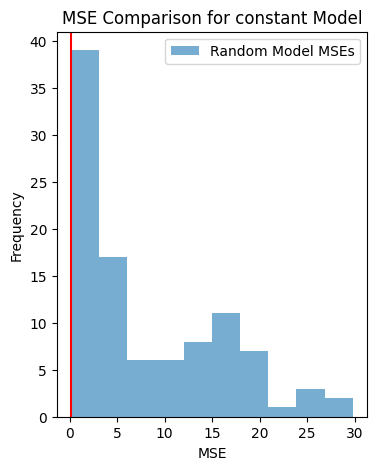

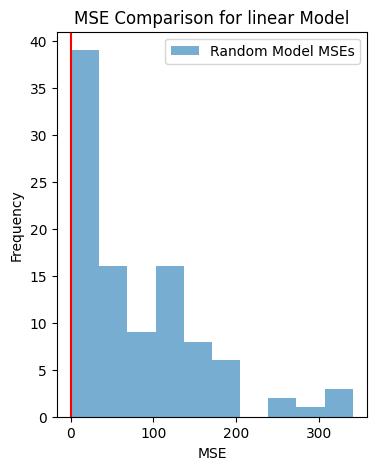

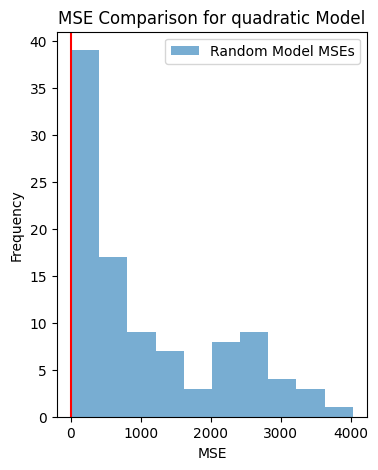

In [9]:
# Exercise #2: verify that the models obtained in exercise #1 are actually optimal fits 
# for the given in-sample dataset (Suggestion: for each of the three cases, generate ~100 
# random models and show the resulting MSE is always equal or greater than the MSE of the
# corresponding optimal model). Illustrate your results in a graph comparing the optimal
# fit error with respect to the randomly generated models' fit errors.

# add your code here...
tags = ['constant','linear','quadratic']
results = []
models = []

in_sample_data = [1.50,2.00,3.50,4.00]

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

in_sample_data = [1.50,2.00,3.50,4.00]

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):
    
    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))

    # Genarate random models
    #if k == 1:
    rd_mse_list = []
    for i in range(100):
        rd_model = generate_random_model(k)
        rd_mse = getmse(in_sample['y'],getgxvals(rd_model,in_sample['x']))
        if rd_mse < inmse:
            print(f"Got a model that has a better mse!")
            break
        rd_mse_list.append(rd_mse)
        #ax[0].plot(out_sample['x'],rd_predictions,label='g(x): best '+tags[k]+' fit')
        #results.append({'Model Order':tags[k],'optimal-model MSE':inmse,'best random-model MSE':best_rd_inmse})


    #models.append(model)
    plt.figure(figsize=(4, 5))  # <-- NEW FIGURE EACH TIME
    plt.hist(rd_mse_list, alpha = 0.6, label= 'Random Model MSEs')
    plt.axvline(inmse, color='red')
    plt.title(f'MSE Comparison for {tags[k]} Model')
    plt.xlabel('MSE')
    plt.ylabel('Frequency')
    plt.legend()

In [10]:
# Any observations about your results from exercises #2?
# This confirms our optimal models are the best models that give the best mses for in sample data

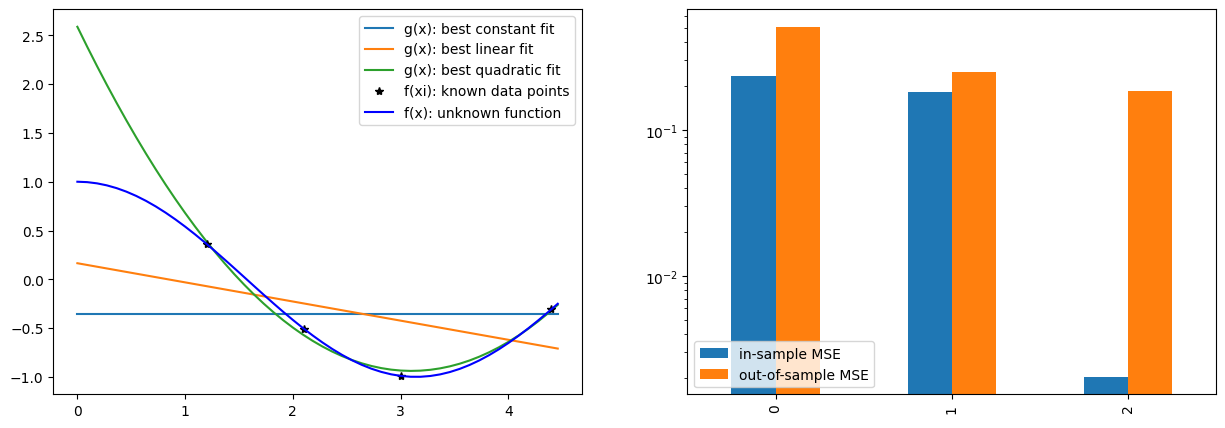

In [11]:
# Exercise #3: reproduce results from exercise #1 but, this time, find a different set of
# four in-sample data points such that the quadratic model exhibits the best out-of-sample MSE

fig, ax = plt.subplots(1,2,figsize=(15,5))
tags = ['constant','linear','quadratic']
results = []
models = []

in_sample_data = [1.20,2.10,3.00,4.40]

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):
    
    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))
    
    predictions = getgxvals(model,out_sample['x'])
    outmse = getmse(out_sample['y'],predictions)
    
    results.append({'Model Order':tags[k],'in-sample MSE':inmse,'out-of-sample MSE':outmse})
    models.append(model)

    ax[0].plot(out_sample['x'],predictions,label='g(x): best '+tags[k]+' fit')

ax[0].plot(in_sample['x'],in_sample['y'],'*k',label='f(xi): known data points')
ax[0].plot(out_sample['x'],out_sample['f'],'-b',label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar',logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()


In [12]:
# Exercise #3 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.235611,0.181857,0.002045
out-of-sample MSE,0.509121,0.251223,0.184873


In [13]:
# How these results compare to your previous results from exercise #1?
# The quadratic model has the best in-sample mse and out-sample mse

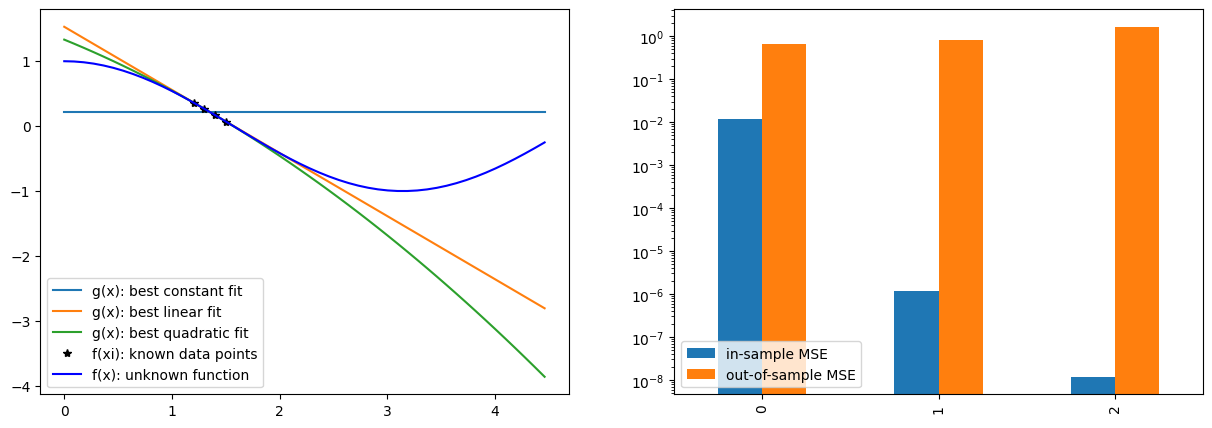

In [14]:
# Exercise #4: can you find a set of four in-sample data points such that the constant model
# exhibits the best out-of-sample MSE? If you succed in doing so, repeat exercises #3 here 
# for such in-sample dataset

fig, ax = plt.subplots(1,2,figsize=(15,5))
tags = ['constant','linear','quadratic']
results = []
models = []

in_sample_data = [1.2,1.3,1.4,1.5]

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):
    
    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))
    
    predictions = getgxvals(model,out_sample['x'])
    outmse = getmse(out_sample['y'],predictions)
    
    results.append({'Model Order':tags[k],'in-sample MSE':inmse,'out-of-sample MSE':outmse})
    models.append(model)

    ax[0].plot(out_sample['x'],predictions,label='g(x): best '+tags[k]+' fit')

ax[0].plot(in_sample['x'],in_sample['y'],'*k',label='f(xi): known data points')
ax[0].plot(out_sample['x'],out_sample['f'],'-b',label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar',logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()


In [15]:
# Exercise #4 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.011821,0.000001,0.0
out-of-sample MSE,0.663876,0.791731,1.646547


In [16]:
# How these results compare to your previous results from exercises #1 and #3?
# The constant model has the highest in-sample MSE but produce the best out-of-sample MSE
# Choosing a good In-sample data will result a good final model

## PART 2: Model Complexity and Learning

In [5]:
# SIMULATIONS: this function allows you to run multiple simulations while varying certain 
# parameters, take a look at it and make sure you understand how it works
# - ind: the in-sample dataset (a dictionary as produced by GETDATA) If this input variable 
#   is not provided, a random in-sample dataset of size nsamples will be used
# - osd: the out-of-sample dataset (a dictionary as produced by GETDATA) If this input varable
#   is not provided, a uniformly distributed dataset of size 100 will be used
# - morder: a list containing the model orders to be considered (default value is [0,1,2])
# - nsamples: the size of the in-sample dataset (ignored if an in-sampled dataset is passed)
# - niter: the total number of iterations to be conducted per model type (notice this variable
#   value is overrited and made equal to 1 if an in-sample dataset is passed)
# - pflag: if TRUE, simulation plots are generated; if FALSE, no plot is generated

def simulations(ind={},osd={},morder=[0,1,2],nsamples=4,niter=1,pflag=False):
    
    if len(ind)>0:
        niter = 1
        rndflag = False
        nsamples = len(ind['x'])
    else:
        rndflag = True
    if len(osd)==0:
        osd = getdata(100)
    tags = ['constant','linear','quadratic']
    results = []

    if pflag: 
        fig, ax = plt.subplots(1,3,figsize=(15,5))

    for modelorder in morder:
        models = []
        in_mse = []
        out_mse = []
        all_predictions = []
    
        for k in tqdm(range(niter),desc=tags[modelorder].rjust(10)+'|'+str(nsamples).rjust(2)):
            
            if rndflag:
                ind=getdata(nsamples,rnd=True,nvr=osd['nvar'],xmin=osd['x'][0],xmax=osd['x'][-1])
                                    
            model = getoptgx(ind['x'],ind['y'],modelorder)
            in_mse.append(getmse(ind['y'],getgxvals(model,ind['x'])))
        
            predictions = getgxvals(model,osd['x'])
            out_mse.append(getmse(osd['y'],predictions))
            models.append(model)
        
            all_predictions.append(predictions)
    
        mean_model = np.array(models).mean(0)
        mean_predictions = getgxvals(mean_model,osd['x'])
    
        if pflag:
            for n,vals in enumerate(all_predictions[:50]):
                if n==0: ax[modelorder].plot(osd['x'],vals,'-y',label='Individual Models')
                else: ax[modelorder].plot(osd['x'],vals,'-y')
            ax[modelorder].plot(osd['x'],osd['f'],'-k',label='Generating Function')
            ax[modelorder].plot(osd['x'],osd['y'],'.k',label='Out-of-sample Data')
            ax[modelorder].plot(osd['x'],mean_predictions,'-r',label='Average Model')
            ax[modelorder].set_ylim(-4,4)
            ax[modelorder].legend(loc='upper right')

        results.append({'Model Order':modelorder,
                        'N Samples':nsamples,
                        'BIAS':getmse(osd['f'],mean_predictions),
                        'VAR':np.array(all_predictions).var(0).mean(),
                        'Noise':np.var(osd['n']),
                        'out_MSE':np.mean(out_mse),
                        'in_MSE':np.mean(in_mse)})
    
    tagseq = ['Model Order','N Samples','in_MSE','out_MSE','BIAS','VAR','Noise']
    return pd.DataFrame(results)[tagseq]

  constant| 4: 100%|██████████| 100000/100000 [00:07<00:00, 14229.56it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:08<00:00, 11813.99it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:10<00:00, 9928.97it/s]


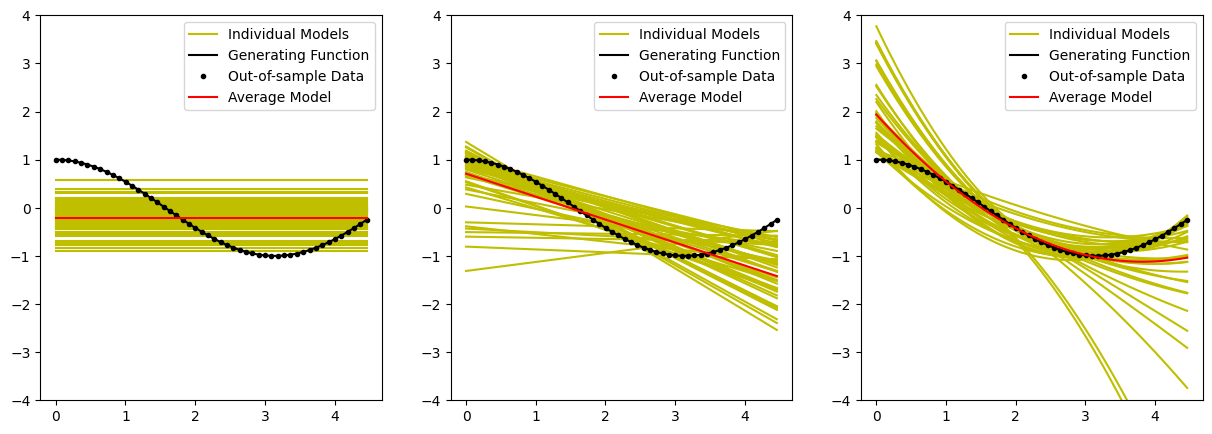

In [18]:
# Exercise #5: use the SIMULATIONS function above to compute average out-of-sample MSE, average 
# in-sample MSE, BIAS and VAR. Consider in-sample datasets of 4 points and an out-of-sample 
# dataset of 50 uniformly distributed points with zero noise variance. Run a large number (~100K) 
# of simulations for each model type (constant, linear, and quadratic). 

out_sample = getdata(50,nvr=0.0)
e5 = simulations(osd=out_sample,nsamples=4,niter=100000,pflag=True)

In [19]:
# Exercise #5 (continuation): add an additional column to the resulting dataframe with the
# sum of the BIAS, VAR and Noise columns; and another additional column containing the MSE
# between out-sample MSE and the newly computed BIAS+VAR+Noise. Display the dataframe.

e5['sum(Bias,Var,Noise)'] = e5['BIAS'] + e5['VAR'] + e5['Noise']

# Add MSE between out_MSE and Bias+Var+Noise
e5['MSE(out_MSE vs Bias+Var+Noise)'] = (e5['out_MSE'] - e5['sum(Bias,Var,Noise)']) ** 2

display(e5)


,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,"sum(Bias,Var,Noise)",MSE(out_MSE vs Bias+Var+Noise)
0,0,4,0.360486,0.605829,0.485296,0.120532,0.0,0.605829,0.000000e+00
1,1,4,0.046061,0.380062,0.158757,0.221305,0.0,0.380062,6.240013e-30
2,2,4,0.002512,0.401345,0.113523,0.287822,0.0,0.401345,5.435745e-30


In [20]:
# What are your main observations from exercises #5?
# The MSE(out_MSE vs Bias+Var+Noise) is close to zero
# That confirms our theory that out_MSE ~= BIAS + VAR since NOISE is 0. Our models are predictable and can be decomposited accurately.

In [9]:
model_labels = ['constant', 'linear', 'quadratic']

In [ ]:
# Exercise #6: use the resuls from exercise #5 to generate MSE bar plots for the three models 
# under consideration. Depict the average in-sample MSEs in one bar plot and the average 
# out-of-sample MSEs in the second one. 

# Plot 1: Average in-sample MSE
plt.figure(figsize=(8, 5))
plt.bar(model_labels, e5['in_MSE'], color='skyblue')
plt.xlabel('Model Order')
plt.ylabel('Average In-Sample MSE')
plt.title('Average In-Sample MSE by Model Order')
plt.tight_layout()
plt.show()

# Plot 2: Average out-of-sample MSE
plt.figure(figsize=(8, 5))
plt.bar(model_labels, e5['out_MSE'], color='salmon')
plt.xlabel('Model Order')
plt.ylabel('Average Out-of-Sample MSE')
plt.title('Average Out-of-Sample MSE by Model Order')
plt.tight_layout()
plt.show()


NameError: name 'e5' is not defined

<Figure size 800x500 with 0 Axes>

In [22]:
# How results from exercises #6 compare to those presented and discussed in class?
# The result is similar to those presented and discussed in class.
# Best in-sample fit does not guarantees best out-of-sample fit

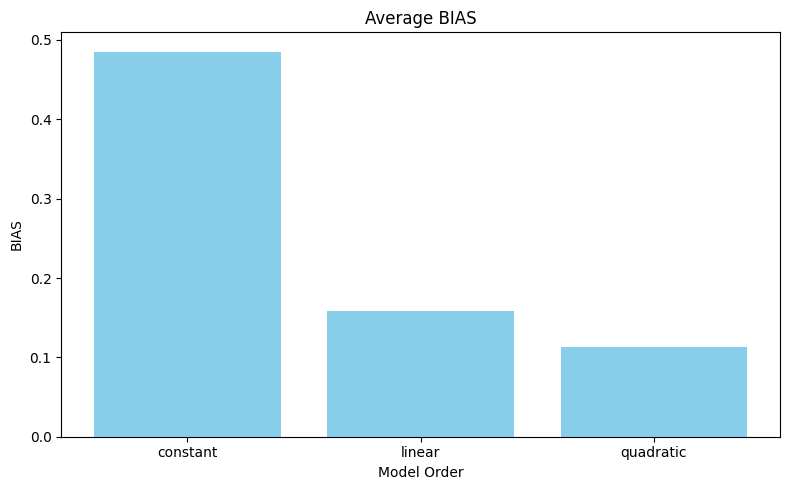

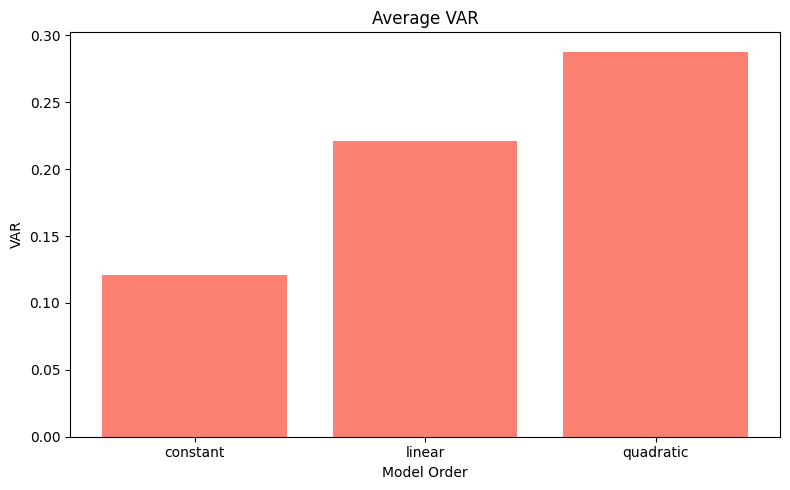

In [23]:
# Exercise #7: use the resuls from exercise #5 to generate MSE bar plots for the three models 
# under consideration. Depict the BIAS in one bar plot and the VAR in the second one. 

# Plot 1: BIAS
plt.figure(figsize=(8, 5))
plt.bar(model_labels, e5['BIAS'], color='skyblue')
plt.xlabel('Model Order')
plt.ylabel('BIAS')
plt.title('Average BIAS')
plt.tight_layout()
plt.show()

# Plot 2: VAR
plt.figure(figsize=(8, 5))
plt.bar(model_labels, e5['VAR'], color='salmon')
plt.xlabel('Model Order')
plt.ylabel('VAR')
plt.title('Average VAR')
plt.tight_layout()
plt.show()


In [24]:
# How results from exercises #7 compare to those presented and discussed in class?
# The result is similar to those presented and discussed in class.
# Higher model complexity is not necessarily better

## PART 3: Sample Complexity and Learning

  constant| 3: 100%|██████████| 100000/100000 [00:06<00:00, 16108.65it/s]
    linear| 3: 100%|██████████| 100000/100000 [00:07<00:00, 13207.03it/s]
 quadratic| 3: 100%|██████████| 100000/100000 [00:09<00:00, 10594.19it/s]
  constant| 4: 100%|██████████| 100000/100000 [00:07<00:00, 13734.18it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:08<00:00, 11635.84it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:10<00:00, 9474.95it/s]
  constant| 5: 100%|██████████| 100000/100000 [00:08<00:00, 12428.46it/s]
    linear| 5: 100%|██████████| 100000/100000 [00:09<00:00, 10485.32it/s]
 quadratic| 5: 100%|██████████| 100000/100000 [00:12<00:00, 7909.16it/s]
  constant| 6: 100%|██████████| 100000/100000 [00:09<00:00, 10690.90it/s]
    linear| 6: 100%|██████████| 100000/100000 [00:10<00:00, 9466.52it/s]
 quadratic| 6: 100%|██████████| 100000/100000 [00:12<00:00, 8160.78it/s]
  constant| 7: 100%|██████████| 100000/100000 [00:09<00:00, 10372.67it/s]
    linear| 7: 100%|██████████| 100000/100

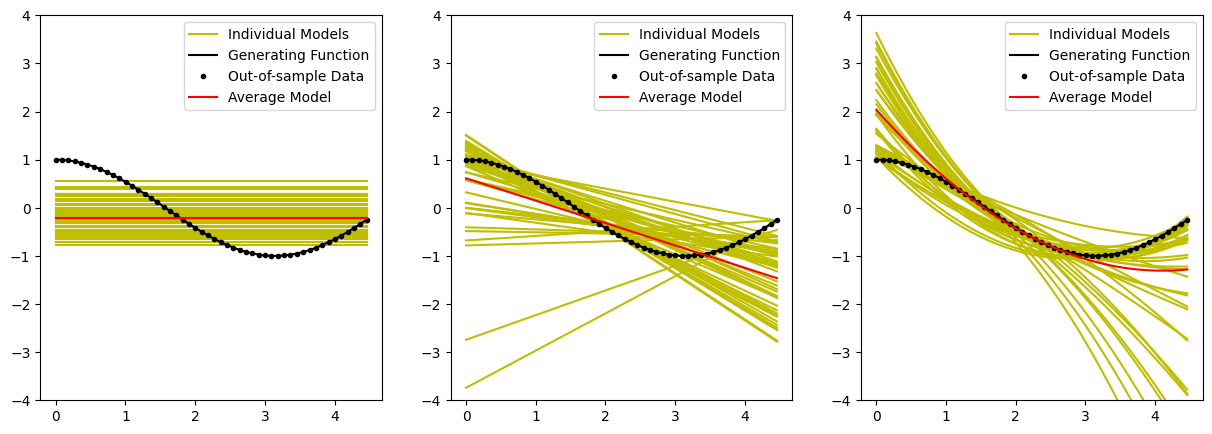

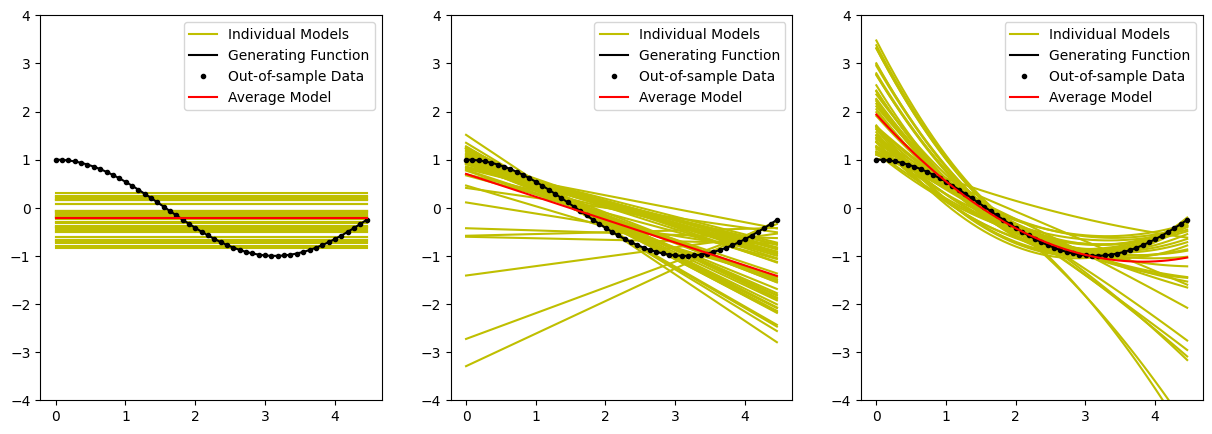

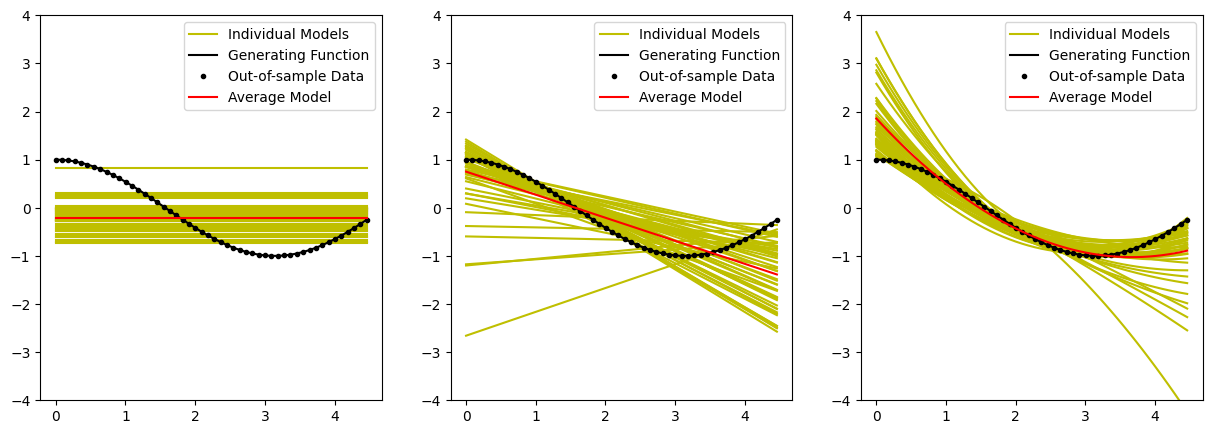

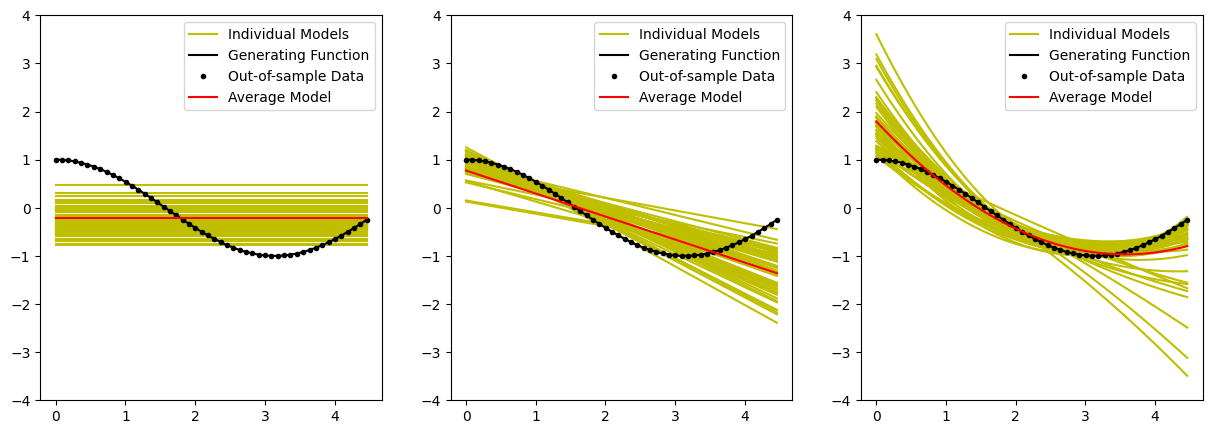

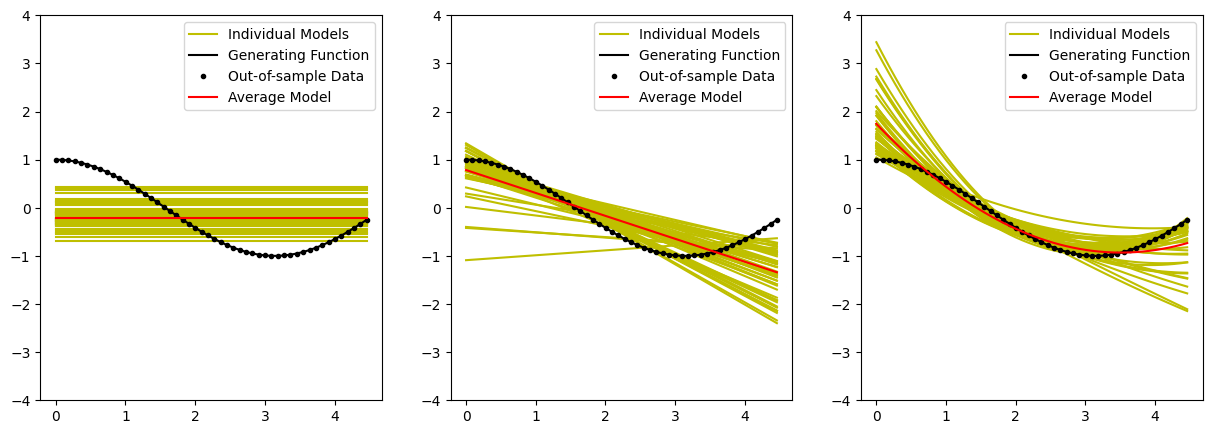

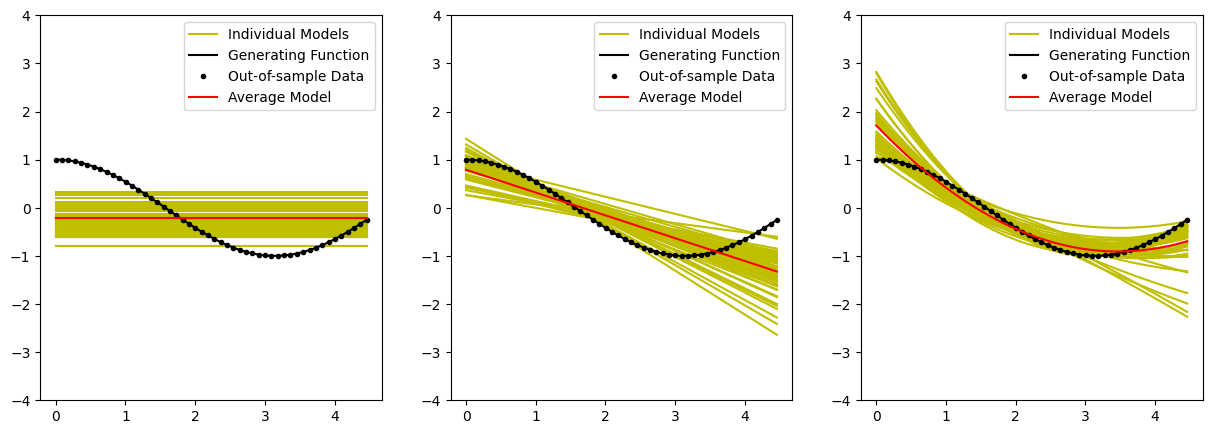

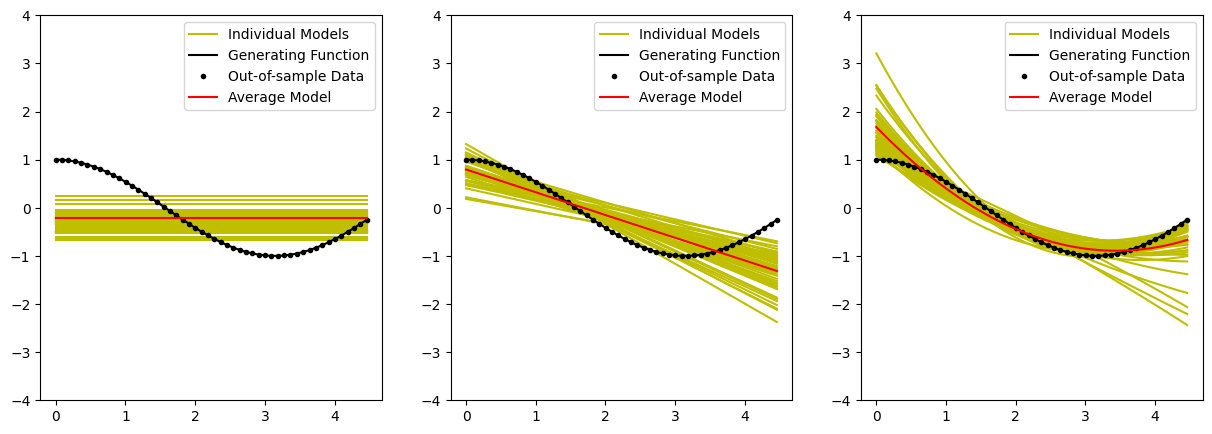

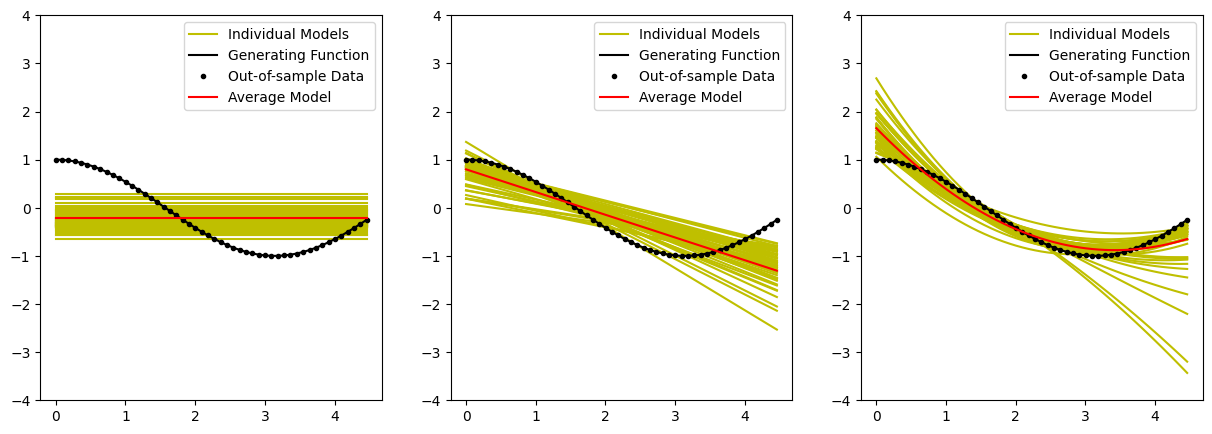

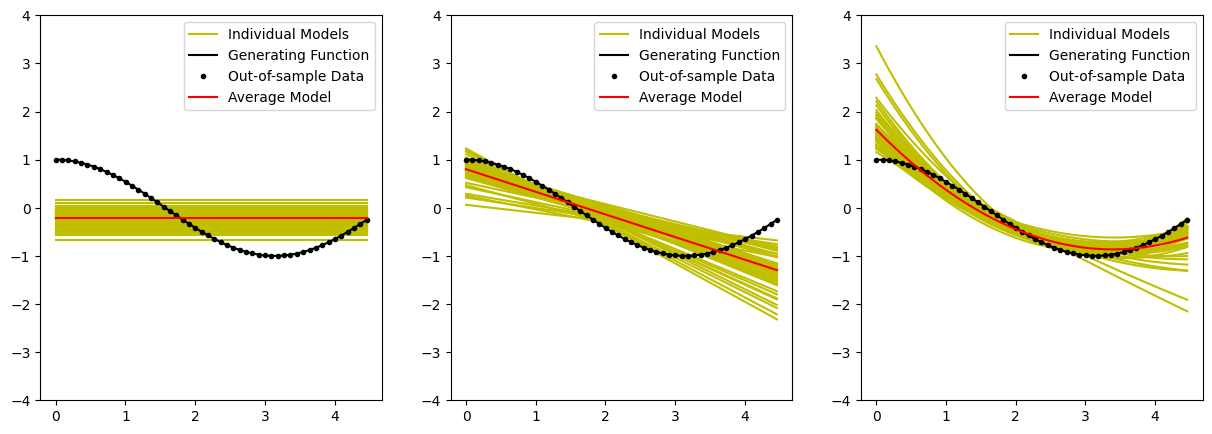

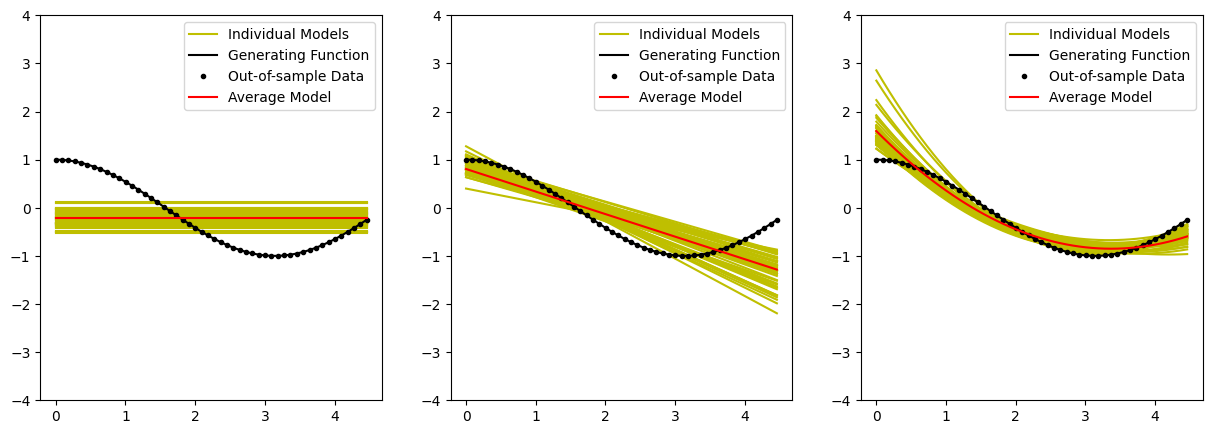

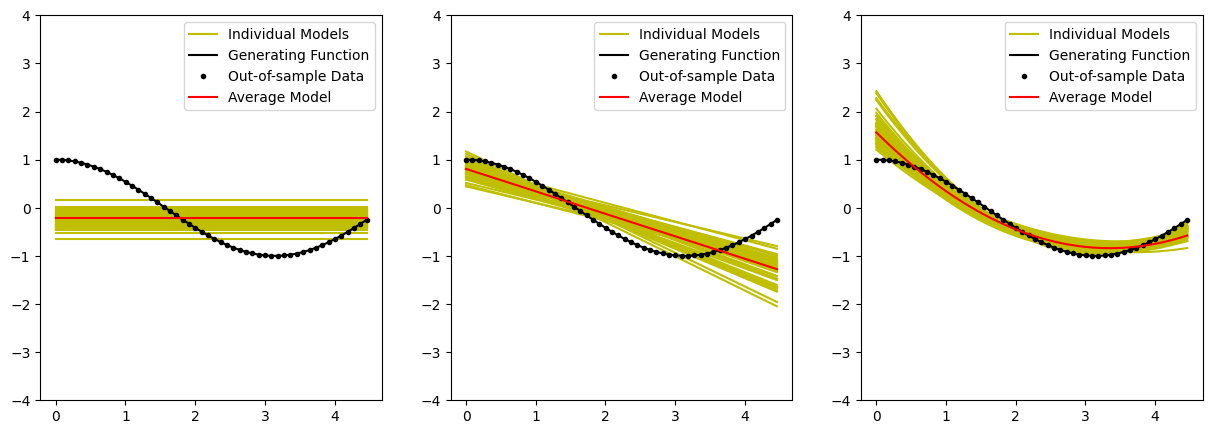

In [25]:
# Exercise 8: implement a loop to conduct similar simulations to the ones in exercise #5
# while varying the nsample parameter (sugested values [3,4,5,6,7,8,9,10,12,15,20]). Consider 
# an out-of-sample dataset of 50 uniformly distributed points with zero noise variance. Again,
# run a large number (~100K) of simulations for each model type and in-sample dataset size.

suggested_vals = [3,4,5,6,7,8,9,10,12,15,20]
e8_results = []
for num_sample in suggested_vals:
    e8_out_sample = getdata(50,nvr=0.0)
    e8 = simulations(osd=e8_out_sample,nsamples=num_sample,niter=100000,pflag=True)
    e8_results.append(e8)


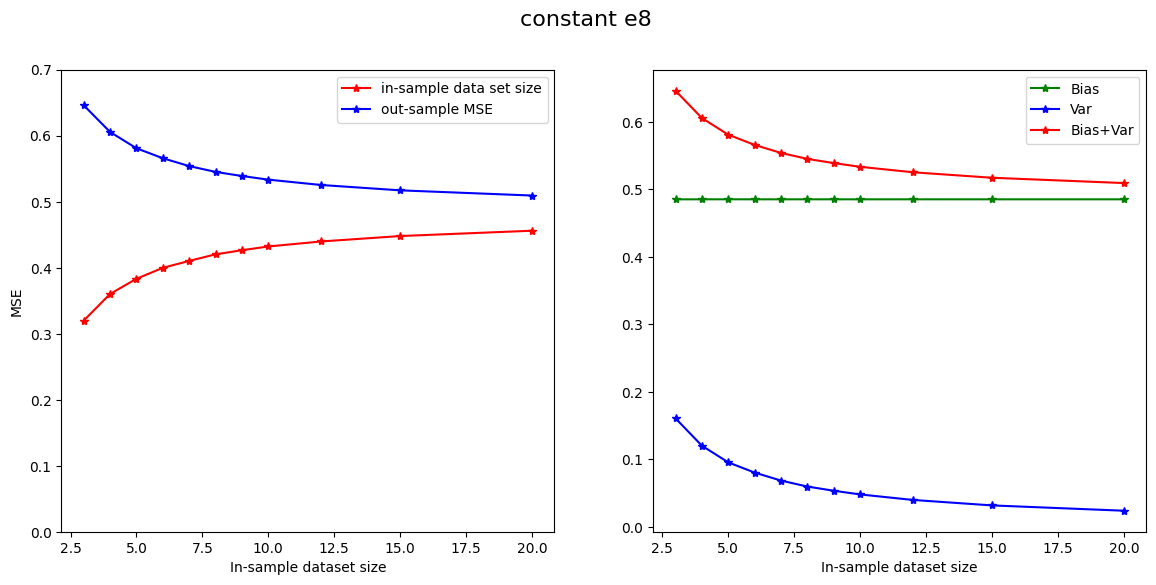

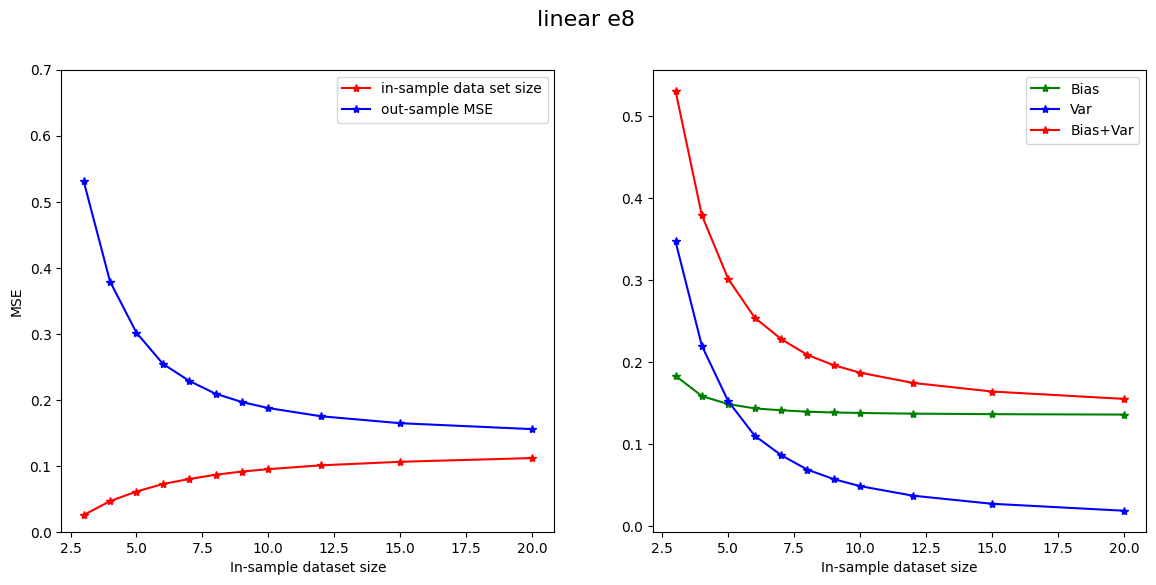

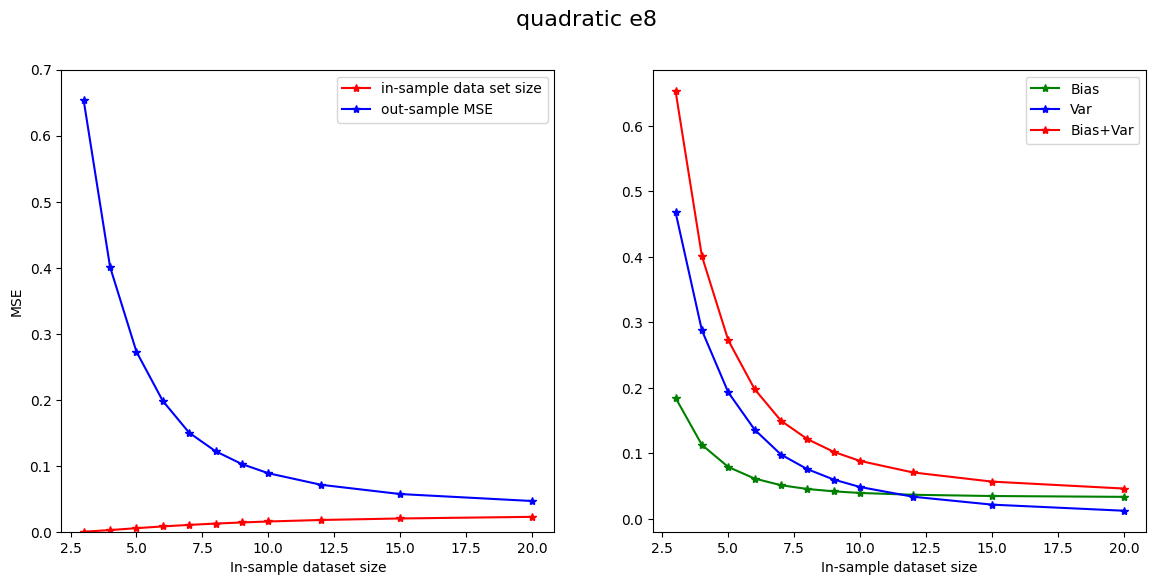

In [26]:
# Exercise 8 (continuation): generate three plots, one for each model type, displaying the
# resulting curves for average in-sample MSE, avergare out-of-sample MSE, BIAS and VAR as 
# a funtion of the nsamples parameter (i.e. the in-sample dataset size)

for type in range(3):
    e8_in_sample_MSE = []
    e8_out_sample_MSE = []
    e8_bias_list = []
    e8_var_list = []

    # Extract values for each sample size
    for e8 in e8_results:
        e8_in_sample_MSE.append(e8.loc[type, 'in_MSE'])
        e8_out_sample_MSE.append(e8.loc[type, 'out_MSE'])
        e8_bias_list.append(e8.loc[type, 'BIAS'])
        e8_var_list.append(e8.loc[type, 'VAR'])

    e8_bias_plus_var = np.array(e8_bias_list) + np.array(e8_var_list)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
    plt.suptitle(f"{model_labels[type]} e8", fontsize=16)
    axes[0].plot(suggested_vals, e8_in_sample_MSE, 'r-*', label='in-sample data set size')
    axes[0].plot(suggested_vals, e8_out_sample_MSE, 'b-*', label='out-sample MSE')
    axes[0].set_xlabel("In-sample dataset size")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].set_ylim([0, 0.7])

    axes[1].plot(suggested_vals, e8_bias_list, 'g-*', label='Bias')
    axes[1].plot(suggested_vals, e8_var_list, 'b-*', label='Var')
    axes[1].plot(suggested_vals, e8_bias_plus_var, 'r-*', label='Bias+Var')
    axes[1].legend()
    axes[1].set_xlabel("In-sample dataset size")


In [27]:
# How results from exercises #8 compare to those presented and discussed in class?
# The result is similar compare to those presented and discussed in class

## PART 4: Exploring the Effects of Noise

  constant| 4: 100%|██████████| 100000/100000 [00:07<00:00, 13725.97it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:08<00:00, 11545.53it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:10<00:00, 9503.51it/s]


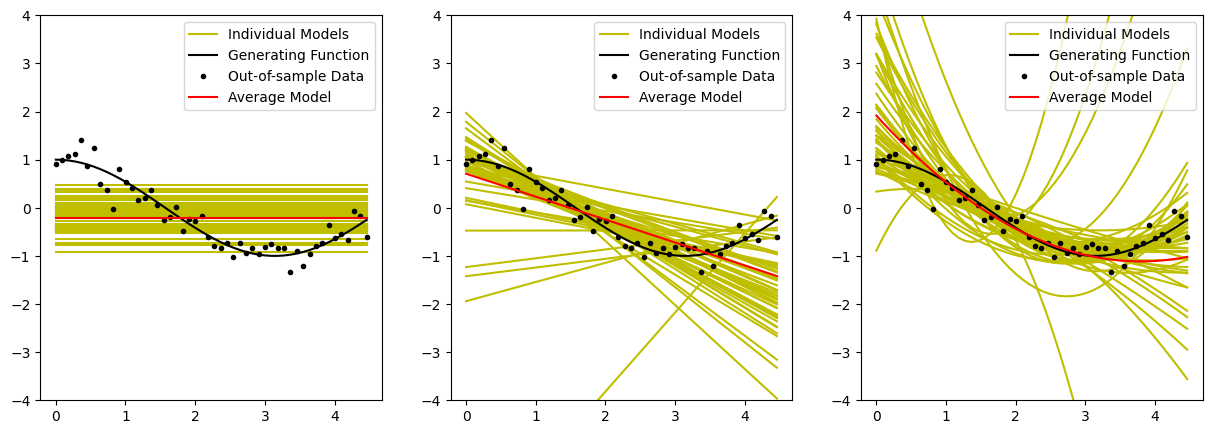

In [6]:
# Exercise #9: repat the simulation in exercise #5 but, this time, add noise with a variance 
# value of 0.05 to the generated data

e9_out_sample = getdata(50,nvr=0.05)
e9 = simulations(osd=e9_out_sample,nsamples=4,niter=100000,pflag=True)


In [7]:
# Exercise #9 (continuation): add an additional column to the resulting dataframe with the
# sum of the BIAS, VAR and Noise columns; and another additional column containing the MSE
# between out-sample MSE and the newly computed BIAS+VAR+Noise. Display the dataframe.

e9['sum(Bias,Var,Noise)'] = e9['BIAS'] + e9['VAR'] + e9['Noise']

# Add MSE between out_MSE and Bias+Var+Noise
e9['MSE(out_MSE vs Bias+Var+Noise)'] = (e9['out_MSE'] - e9['sum(Bias,Var,Noise)']) ** 2

display(e9)

,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,"sum(Bias,Var,Noise)",MSE(out_MSE vs Bias+Var+Noise)
0,0,4,0.397154,0.627181,0.485278,0.120258,0.049773,0.655308,0.000791
1,1,4,0.070866,0.482992,0.158696,0.281070,0.049773,0.489538,0.000043
2,2,4,0.015074,183.405672,0.107924,183.254020,0.049773,183.411717,0.000037


In [8]:
# How do resuts from exercise #9 compare to those in exercise #5? What are the effects of noise?
# The MSE(out_MSE vs Bias+Var+Noise) is not close to zero like e5 anymore.
# The noise contaminated the data, shift its behaviors and become less predictable.

In [2]:
# SIMULATIONS: this function allows you to run multiple simulations while varying certain 
# parameters, take a look at it and make sure you understand how it works
# - ind: the in-sample dataset (a dictionary as produced by GETDATA) If this input variable 
#   is not provided, a random in-sample dataset of size nsamples will be used
# - osd: the out-of-sample dataset (a dictionary as produced by GETDATA) If this input varable
#   is not provided, a uniformly distributed dataset of size 100 will be used
# - morder: a list containing the model orders to be considered (default value is [0,1,2])
# - nsamples: the size of the in-sample dataset (ignored if an in-sampled dataset is passed)
# - niter: the total number of iterations to be conducted per model type (notice this variable
#   value is overrited and made equal to 1 if an in-sample dataset is passed)
# - pflag: if TRUE, simulation plots are generated; if FALSE, no plot is generated

def simulations_ex10(ind={},osd={},morder=[0,1,2],nsamples=4,niter=1,pflag=False):
    
    if len(ind)>0:
        niter = 1
        rndflag = False
        nsamples = len(ind['x'])
    else:
        rndflag = True
    if len(osd)==0:
        osd = getdata(100)
    tags = ['constant','linear','quadratic']
    results = []

    if pflag: 
        fig, ax = plt.subplots(1,3,figsize=(15,5))

    for modelorder in morder:
        models = []
        in_mse = []
        out_mse = []
        all_predictions = []
        noise_collections = []
    
        for k in tqdm(range(niter),desc=tags[modelorder].rjust(10)+'|'+str(nsamples).rjust(2)):
            
            if rndflag:
                ind=getdata(nsamples,rnd=True,nvr=osd['nvar'],xmin=osd['x'][0],xmax=osd['x'][-1])
                                    
            model = getoptgx(ind['x'],ind['y'],modelorder)
            in_mse.append(getmse(ind['y'],getgxvals(model,ind['x'])))
        
            predictions = getgxvals(model,osd['x'])
            out_mse.append(getmse(osd['y'],predictions))
            models.append(model)
        
            all_predictions.append(predictions)
            noise_collections.append(np.array(osd['y']) - np.array(osd['f']))
    
        mean_model = np.array(models).mean(0)
        mean_predictions = getgxvals(mean_model,osd['x'])
    
        if pflag:
            for n,vals in enumerate(all_predictions[:50]):
                if n==0: ax[modelorder].plot(osd['x'],vals,'-y',label='Individual Models')
                else: ax[modelorder].plot(osd['x'],vals,'-y')
            ax[modelorder].plot(osd['x'],osd['f'],'-k',label='Generating Function')
            ax[modelorder].plot(osd['x'],osd['y'],'.k',label='Out-of-sample Data')
            ax[modelorder].plot(osd['x'],mean_predictions,'-r',label='Average Model')
            ax[modelorder].set_ylim(-4,4)
            ax[modelorder].legend(loc='upper right')

        noise_stack = np.stack(noise_collections)
        noise_variance = noise_stack.var()

        results.append({'Model Order':modelorder,
                        'N Samples':nsamples,
                        'BIAS':getmse(osd['f'],mean_predictions),
                        'VAR':np.array(all_predictions).var(0).mean(),
                        'Noise':noise_variance,
                        'out_MSE':np.mean(out_mse),
                        'in_MSE':np.mean(in_mse)})
    
    tagseq = ['Model Order','N Samples','in_MSE','out_MSE','BIAS','VAR','Noise']
    return pd.DataFrame(results)[tagseq]

  constant| 4: 100%|██████████| 100000/100000 [00:07<00:00, 12704.65it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:09<00:00, 10451.13it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:11<00:00, 8690.07it/s]


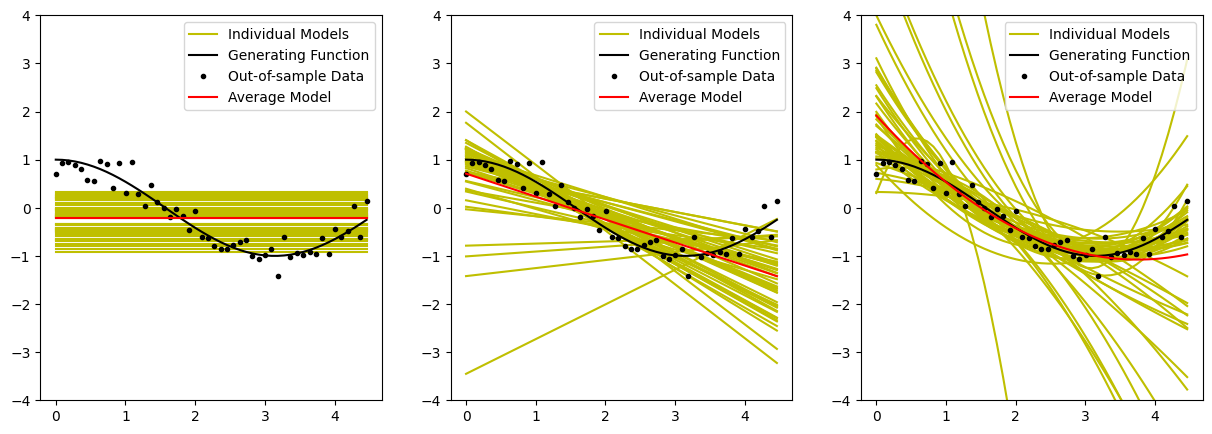

In [10]:
e10_out_sample = getdata(50,nvr=0.05)
e10 = simulations_ex10(osd=e10_out_sample,nsamples=4,niter=100000,pflag=True)

In [11]:
# Exercise #10: in theory, out_MSE = BIAS + VAR + var(Noise), can you explain the mismatch 
# observed in your results from exercise #9? If you come with an explanation for it, can you 
# run another simulation to verify your hypothesis?

#We calculate the noise as the var of osd, but it's only calculated once, causing the mismatch.
e10['sum(Bias,Var,Noise)'] = e10['BIAS'] + e10['VAR'] + e10['Noise']
e10['MSE(out_MSE vs Bias+Var+Noise)'] = (e10['out_MSE'] - e10['sum(Bias,Var,Noise)']) ** 2

display(e10)


,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,"sum(Bias,Var,Noise)",MSE(out_MSE vs Bias+Var+Noise)
0,0,4,0.397041,0.607315,0.485337,0.120271,0.04449,0.650098,0.001830
1,1,4,0.071137,0.496913,0.158894,0.281103,0.04449,0.484488,0.000154
2,2,4,0.015010,81.663973,0.098843,81.481082,0.04449,81.624415,0.001565


In [12]:
# What are your main observations from exercise #10?
# The MSE(out_MSE vs Bias+Var+Noise) is closer to zero for all models, confirming our hypothese from #9

  constant| 6: 100%|██████████| 100000/100000 [00:09<00:00, 10385.83it/s]
    linear| 6: 100%|██████████| 100000/100000 [00:11<00:00, 8795.15it/s]
 quadratic| 6: 100%|██████████| 100000/100000 [00:12<00:00, 7846.57it/s]
  constant| 8: 100%|██████████| 100000/100000 [00:11<00:00, 9067.47it/s]
    linear| 8: 100%|██████████| 100000/100000 [00:12<00:00, 7895.30it/s]
 quadratic| 8: 100%|██████████| 100000/100000 [00:14<00:00, 6829.25it/s]
  constant|10: 100%|██████████| 100000/100000 [00:12<00:00, 7853.29it/s]
    linear|10: 100%|██████████| 100000/100000 [00:14<00:00, 6919.23it/s]
 quadratic|10: 100%|██████████| 100000/100000 [00:16<00:00, 6032.45it/s]
  constant|15: 100%|██████████| 100000/100000 [00:16<00:00, 5910.57it/s]
    linear|15: 100%|██████████| 100000/100000 [00:18<00:00, 5289.88it/s]
 quadratic|15: 100%|██████████| 100000/100000 [00:21<00:00, 4651.45it/s]
  constant|20: 100%|██████████| 100000/100000 [00:21<00:00, 4667.16it/s]
    linear|20: 100%|██████████| 100000/100000 [00:

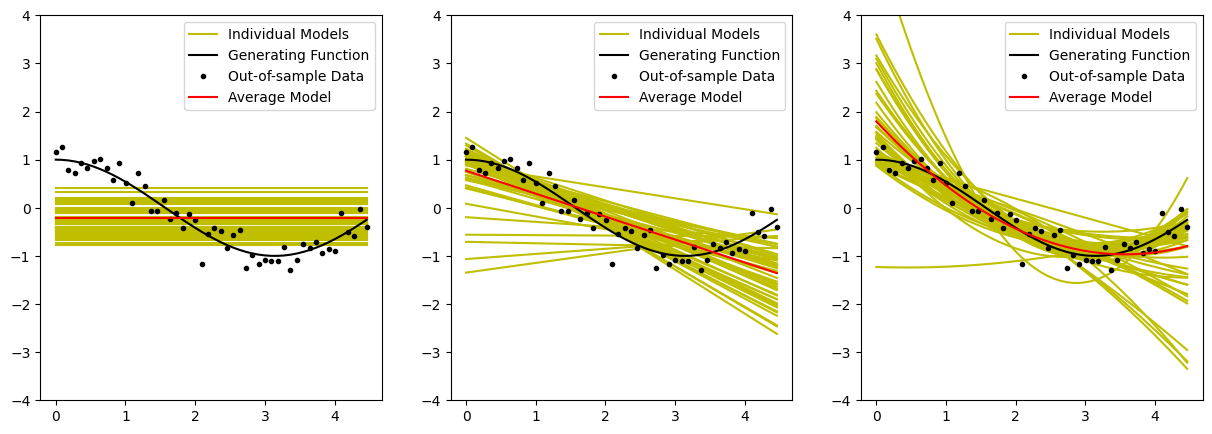

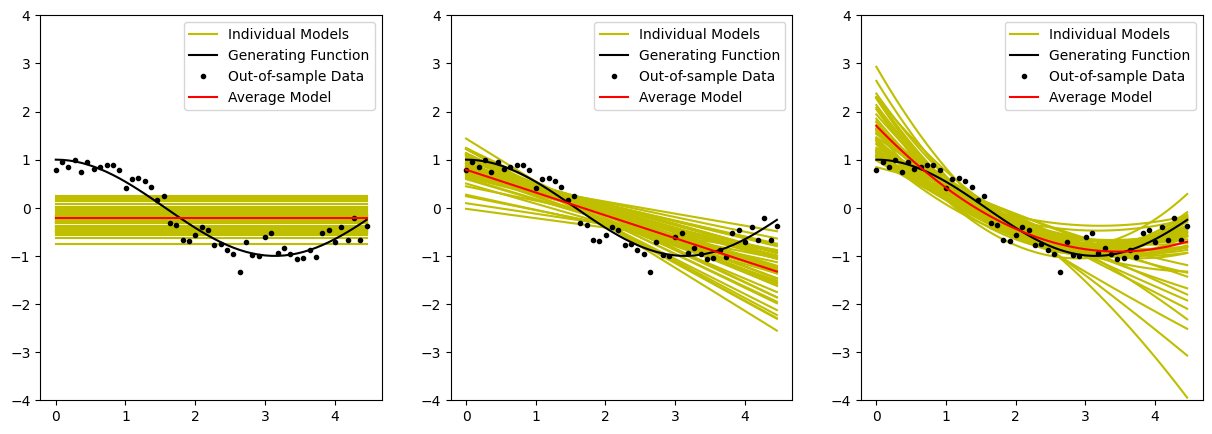

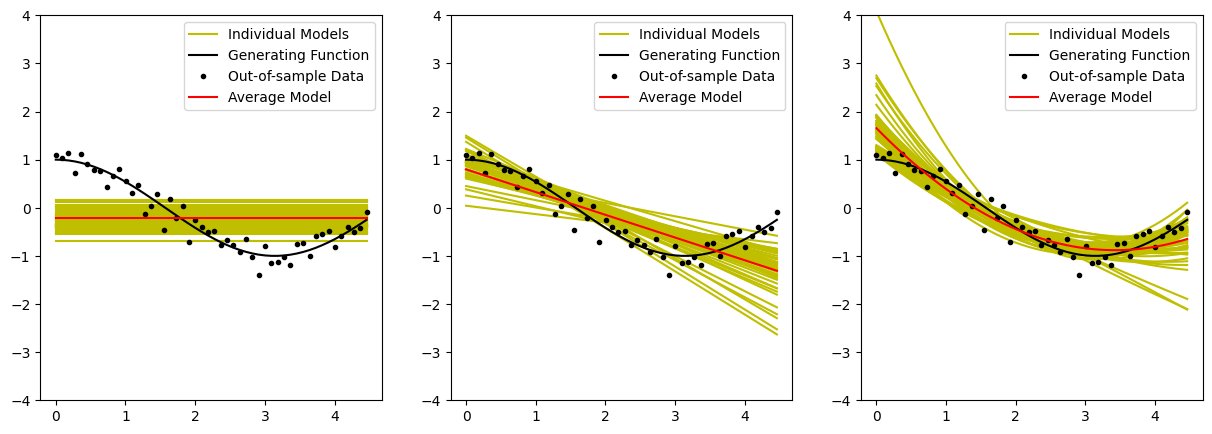

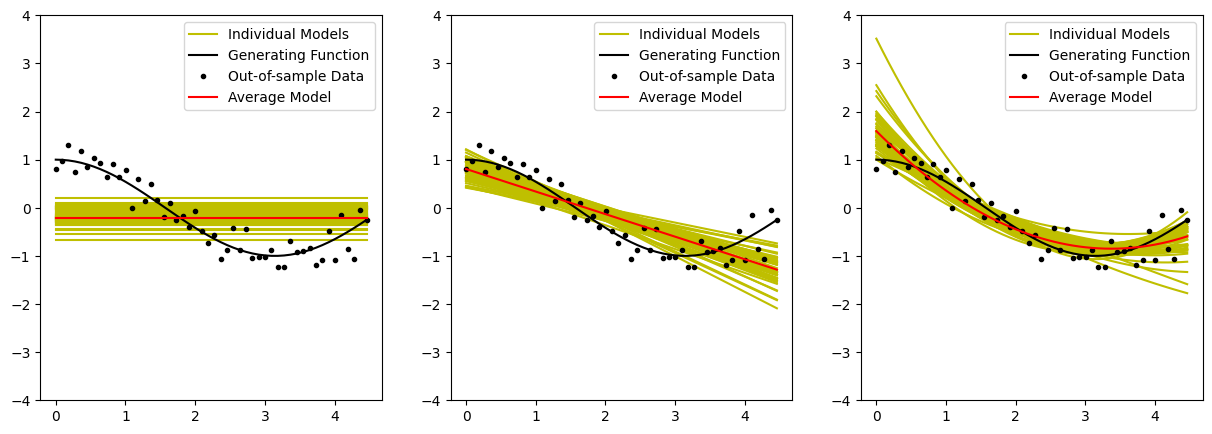

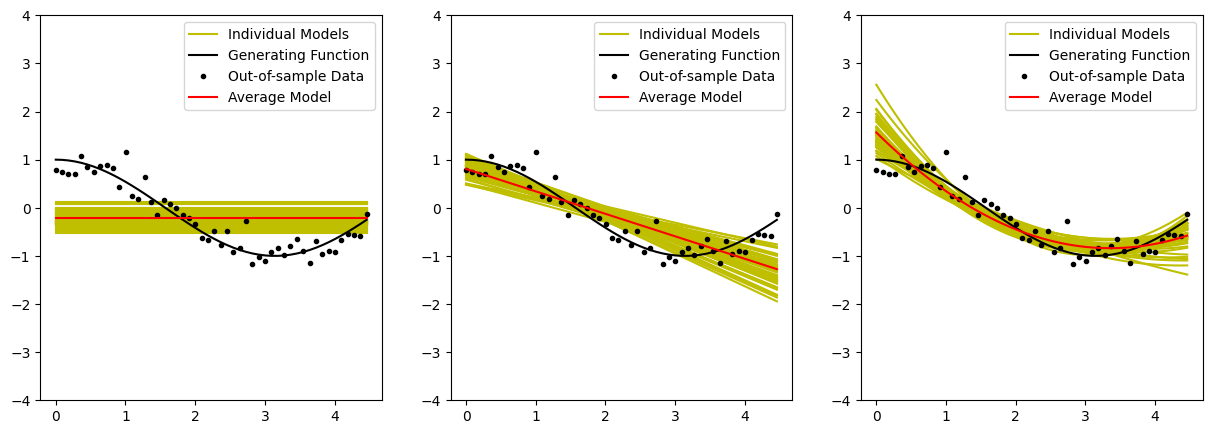

In [7]:
# Exercise #11: repeat exercise #8 but, again, adding noise with a variance value of 0.05;
# you can use a smaller set of nsamples values this time (sugested values [6,8,10,15,20]).

suggested_vals = [6,8,10,15,20]
e11_results = []
for num_sample in suggested_vals:
    e11_out_sample = getdata(50,nvr=0.05)
    e11 = simulations_ex10(osd=e11_out_sample,nsamples=num_sample,niter=100000,pflag=True)
    e11_results.append(e11)


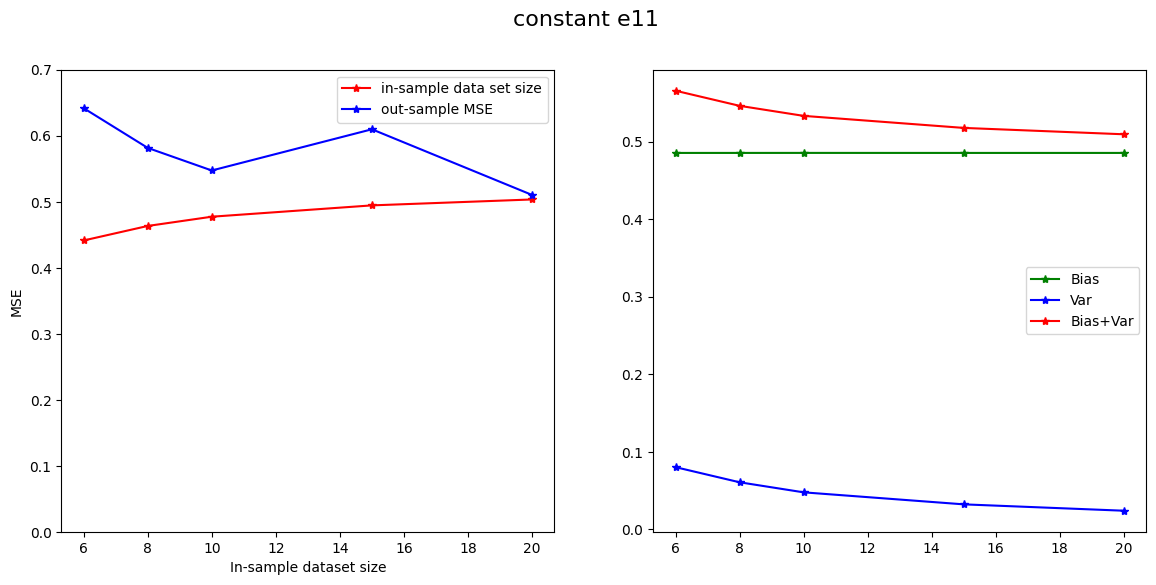

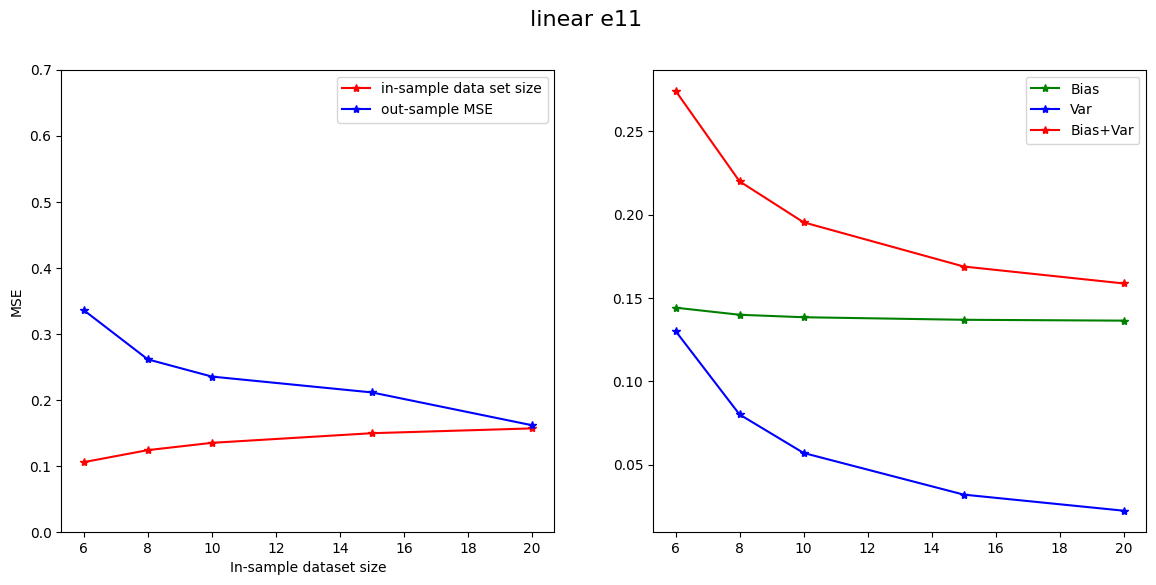

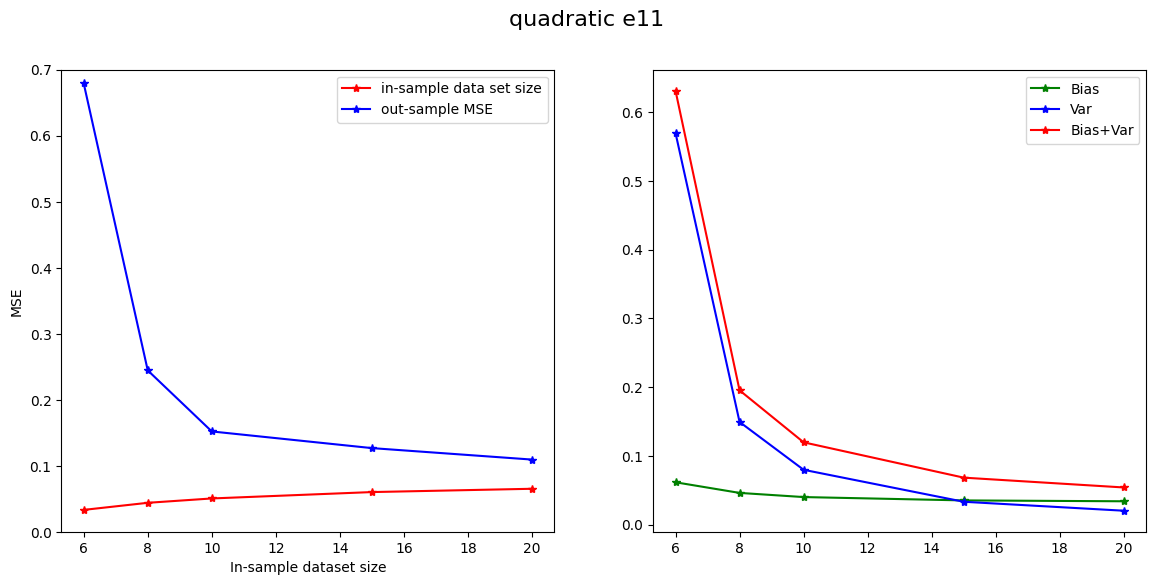

In [10]:
# Exercise #11 (continuation): generate plots to compare behaviors between averages MSEs, BIAS,
# and VAR for simulations in exercise #8 (no noise added) and exercise #11 (with noise added).

for type in range(3):
    e11_in_sample_MSE = []
    e11_out_sample_MSE = []
    e11_bias_list = []
    e11_var_list = []

    # Extract values for each sample size
    for e11 in e11_results:
        e11_in_sample_MSE.append(e11.loc[type, 'in_MSE'])
        e11_out_sample_MSE.append(e11.loc[type, 'out_MSE'])
        e11_bias_list.append(e11.loc[type, 'BIAS'])
        e11_var_list.append(e11.loc[type, 'VAR'])

    e11_bias_plus_var = np.array(e11_bias_list) + np.array(e11_var_list)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
    plt.suptitle(f"{model_labels[type]} e11", fontsize=16)
    axes[0].plot(suggested_vals, e11_in_sample_MSE, 'r-*', label='in-sample data set size')
    axes[0].plot(suggested_vals, e11_out_sample_MSE, 'b-*', label='out-sample MSE')
    axes[0].set_xlabel("In-sample dataset size")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].set_ylim([0, 0.7])

    axes[1].plot(suggested_vals, e11_bias_list, 'g-*', label='Bias')
    axes[1].plot(suggested_vals, e11_var_list, 'b-*', label='Var')
    axes[1].plot(suggested_vals, e11_bias_plus_var, 'r-*', label='Bias+Var')
    axes[1].legend()



In [11]:
# What are your main conclusions from exercise #11?
# When noise is present, MSE is higher overall. Noise introduces an unavoidable error on the model,
# regardless of the model complexity. The effect is more noticeable in simpler models


## PART 5: Term Project Team Formation

In [12]:
# Work with your classmates to decide on the team members for your term project and list all team
# members in your team here:

# Project: Vegetable Identifier
# Members:
# Quoc Dung Lam
# Ianna Duran
# Trevor O’Neil